In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load the data
df = pd.read_csv('../data/q2_customers.csv')

# 2. Scale the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Create a DataFrame for scaled data to keep track of columns
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)
df_scaled.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


Why Scaling is Essential:                                      K-Means clustering relies on the Euclidean Distance formula:       d(p, q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}               Features with larger numeric ranges (e.g., Annual Spend) will dominate the distance calculation over smaller features (e.g., Visits). Scaling ensures each feature contributes equally to the formation of clusters.

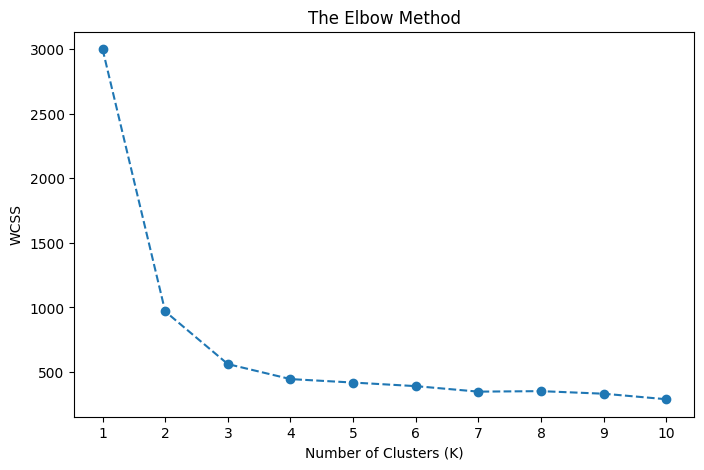

In [2]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.show()

Justifying K:                                                   Looking at the plot, the "elbow" or the point of inflection appears at K = 3 (or 4, depending on the specific curve). Beyond this point, the reduction in WCSS becomes linear and less significant, indicating that K=3 provides an optimal balance between simplicity and detail.

In [3]:
# 1. Fit K-Means
optimal_k = 3 # Change to 4 if your elbow looks clearer there
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

# 2. Print Centroids
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
print("Cluster Centroids (Scaled):")
display(centroids)

# Business Interpretation using Inverse Transform or Groupby
print("\n--- Mean values per cluster ---")
display(df.groupby('cluster').mean())

Cluster Centroids (Scaled):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968



--- Mean values per cluster ---


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
cluster,,,,,,
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster Interpretation:                                       Cluster 0: "The High-Value Loyalists" — High spend, large baskets, and frequent visits.

Cluster 1: "The Window Shoppers" — Young, low spend, but very high monthly visits.

Cluster 2: "The Occasional Big-Spenders" — Older demographic, high basket size, but very high "days since last visit" (inactive).

In [4]:
# 1. Apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# 2. Variance Ratio
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

# 3. Feature Loadings
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=df.columns[:-1])
print("\nFeature Loadings:")
display(loadings)

Explained Variance Ratio: [0.83560354 0.05568764]

Feature Loadings:


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


PC interpretation:
PC1 likely captures Total Engagement (high loading on annual spend and basket size), while PC2 might capture Recency/Frequency (high loading on days since last visit or monthly visits).

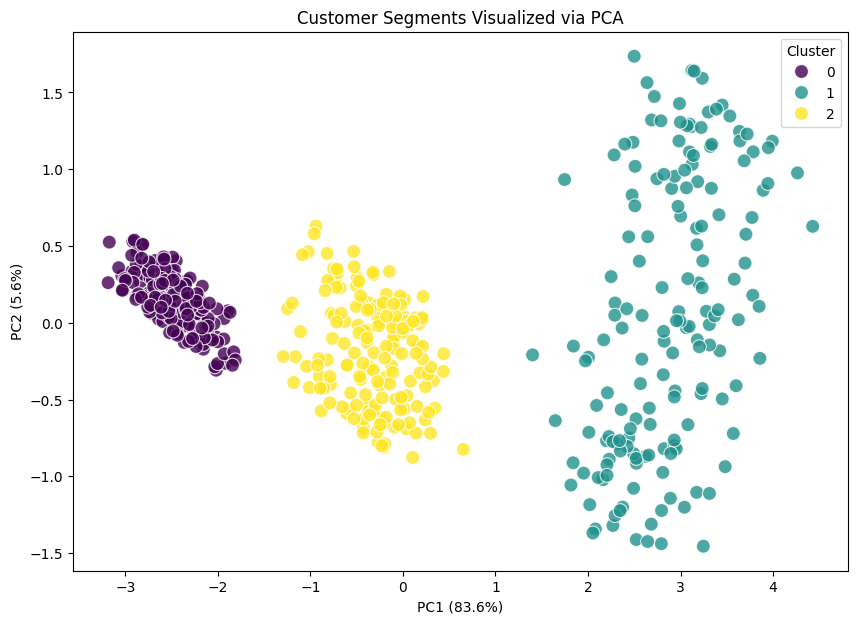

In [5]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=df['cluster'], 
                palette='viridis', s=100, alpha=0.8)

plt.title('Customer Segments Visualized via PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Cluster')
plt.show()